### Importing modules

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from matplotlib.patches import Ellipse
import numpy as np
from matplotlib import font_manager

In [2]:
font_manager.fontManager.addfont('../data/fonts/Arial.ttf')
font_manager.fontManager.addfont('../data/fonts/Arial_Bold.ttf')
font_manager.fontManager.addfont('../data/fonts/Arial_Bold_Italic.ttf')
plt.rcParams['font.family'] = 'Arial'

### PCA plot

In [3]:
def plot_ellipse(ax, data, color, label):
    """
    Plot an ellipse representing the 95% confidence interval of the data points.
    """
    mean = np.mean(data, axis=0)
    cov = np.cov(data.T)
    lambda_, v = np.linalg.eig(cov)
    lambda_ = np.sqrt(lambda_)
    
    # Scaling factor for the 95% confidence interval
    scaling_factor = np.sqrt(5.991)  # Chi-squared value for 2 degrees of freedom and 95% confidence
    
    # Calculate the angle of the ellipse
    angle = np.degrees(np.arctan2(*v[:, 0][::-1]))
    
    # Width and height are 2 standard deviations, scaled to the 95% confidence interval
    width, height = 2 * lambda_ * scaling_factor
    
    ellipse = Ellipse(xy=mean,
                      width=width, height=height,
                      angle=angle, color=color, linestyle='--', linewidth=1, fill=False)
    
    ax.add_patch(ellipse)
    ax.scatter(data[:, 0], data[:, 1], s=4, color=color)


Axes 1 explains 9.083669279087301% of the variance
Axes 2 explains 7.591918449840261% of the variance


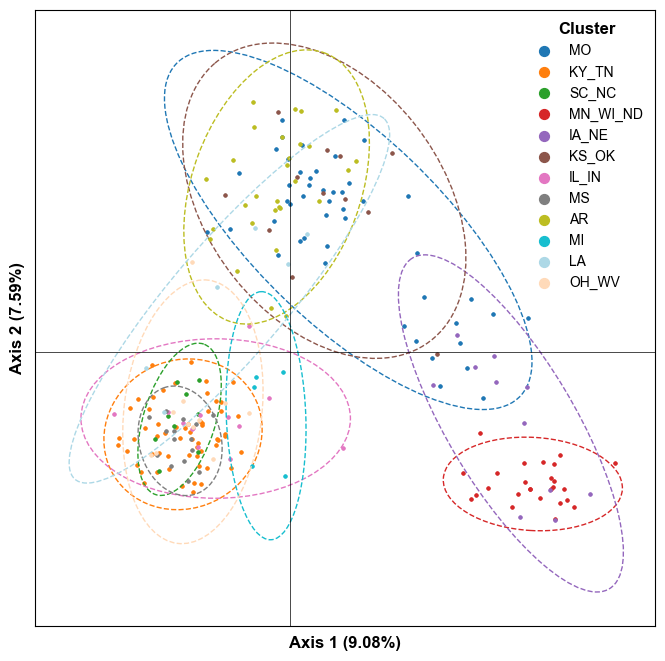

In [23]:
X = pd.read_csv('../data/genotypes/genotype_matrix.csv', index_col=0)
reduction_obj = PCA(n_components=2, random_state=0)
projection = reduction_obj.fit_transform(X)
projection = pd.DataFrame(projection, columns=['PCA1', 'PCA2'])

bam = pd.read_table('../data/merged_bams/bams_4_rcr.txt', header=None)
bam.columns = ['Sample_ID']
bam['Sample_ID'] = bam['Sample_ID'].apply(lambda x: x.split('/')[-1].split('.')[0])

meta = pd.read_csv('../config/meta_apriori_jittered.csv')
bam = bam.merge(meta, left_on='Sample_ID', right_on='Sample_ID')
projection = projection.merge(bam['POP'], left_index=True, right_index=True)

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 
          'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray', 
          'tab:olive', 'tab:cyan', 'lightblue', 'peachpuff']
fig, ax = plt.subplots(figsize=(8,8))

for idx, pop in enumerate(projection.POP.unique()):
    subset = projection.loc[projection.POP == pop]
    ax.scatter(x='PCA1',y='PCA2', color=colors[idx], s=4, data=subset, label=pop)
    plot_ellipse(ax, subset[['PCA1','PCA2']].values, colors[idx], pop)
    
ax.set_xticks([])
ax.set_yticks([])
ax.axhline(y=0, color='black', linewidth=0.5)
ax.axvline(x=0, color='black', linewidth=0.5)

print(f"Axes 1 explains {reduction_obj.explained_variance_[0]}% of the variance")
print(f"Axes 2 explains {reduction_obj.explained_variance_[1]}% of the variance")

ax.set_xlabel(f'Axis 1 ({round(reduction_obj.explained_variance_[0],2)}%)', fontname='Arial', fontweight='bold', fontsize=12)
ax.set_ylabel(f'Axis 2 ({round(reduction_obj.explained_variance_[1],2)}%)', fontname='Arial', fontweight='bold', fontsize=12)

legend = ax.legend(title='Cluster', scatterpoints=1)
plt.setp(legend.get_title(), fontsize=12, fontweight='bold')
legend.set_frame_on(False)
for handle in legend.legendHandles:
    handle._sizes = [50]


In [26]:
pd.read_table('../data/genotypes/geno5.geno').T

,0,1,2,3,4,5,6,7,8,9,...,1695,1696,1697,1698,1699,1700,1701,1702,1703,1704
CM063496.1,CM063496.1,CM063496.1,CM063496.1,CM063496.1,CM063496.1,CM063496.1,CM063496.1,CM063496.1,CM063496.1,CM063496.1,...,JAVLSZ010000009.1,JAVLSZ010000009.1,JAVLSZ010000009.1,JAVLSZ010000009.1,JAVLSZ010000009.1,JAVLSZ010000009.1,JAVLSZ010000009.1,JAVLSZ010000009.1,JAVLSZ010000009.1,JAVLSZ010000009.1
2528184,5226495,5493333,8107817,17996380,34489553,40787161,44531719,84610005,85582107,85801190,...,55759912,56609802,58231217,59350726,61403359,62772786,62772793,63930111,66720378,70860738
TT,CC,AA,AA,NN,AA,CC,CC,GG,CC,GG,...,GA,GG,AA,AA,GG,CC,CC,AA,TT,AA
TT.1,AA,AA,TT,NN,AA,CC,CC,GG,CC,GG,...,GG,GG,AA,AA,GG,CC,CT,AA,TT,AA
TT.2,AA,AA,TT,GG,AA,CC,CC,GG,AA,GG,...,GG,AA,AA,AA,GG,CC,CC,AA,TT,AA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TC.2,AC,AA,TT,GA,AA,CC,CC,GG,CA,GG,...,GA,GG,AA,NN,NN,CC,CT,AA,TT,AT
TT.234,NN,NN,TT,GG,AA,CC,CC,GG,AA,GG,...,GG,GG,AA,NN,GG,CC,CC,AA,TT,AA
TT.235,AC,AA,TT,GA,AA,CC,CC,GA,AA,GG,...,GA,GG,AA,AA,GG,CC,CC,AA,TT,AT
TT.236,AC,AA,TT,AA,AA,CC,CC,GG,CC,GG,...,GG,GG,AA,AA,GG,CC,CC,NN,NN,AA
